In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


In [6]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("ANÁLISIS EXPLORATORIO DE DATOS - TRÁFICO URBANO")
print("-"*60)

archivos = [
    '../../datos/completo/lunes-03-11.csv',
    '../../datos/completo/martes-11-11.csv', 
    '../../datos/completo/miercoles-12-11.csv',
    '../../datos/completo/jueves-06-11.csv',
    '../../datos/completo/viernes-14-11.csv'
]

dfs = []
for archivo in archivos:
    df = pd.read_csv(archivo)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print(f"Total de registros: {len(data)}")
print(f"Días analizados: {data['Dia_Semana'].nunique()}")
print(f"Semáforos: {data['Semaforo_ID'].nunique()}")

ANÁLISIS EXPLORATORIO DE DATOS - TRÁFICO URBANO
------------------------------------------------------------
Total de registros: 3801
Días analizados: 5
Semáforos: 4


In [ ]:
print("INFORMACIÓN DEL DATASET")
print("ESTADÍSTICAS DESCRIPTIVAS")
print("\n" + "-"*60)
print(data.describe())

data['Hora'] = pd.to_datetime(data['Hora_Inicio'], format='%H:%M:%S').dt.hour

dias_map = {1: 'Lunes', 2: 'Martes', 3: 'Miércoles', 4: 'Jueves', 5: 'Viernes'}
data['Dia_Nombre'] = data['Dia_Semana'].map(dias_map)

INFORMACIÓN DEL DATASET
ESTADÍSTICAS DESCRIPTIVAS

------------------------------------------------------------
       Total_Vehiculos  Tiempo_Medio_s  Ocupacion_Espacial_%   Dia_Semana  \
count      3801.000000     3801.000000           3801.000000  3801.000000   
mean          5.996580        3.078992             10.871436     3.000000   
std           3.161568        2.523647              6.545240     1.413655   
min           0.000000        0.000000              0.010000     1.000000   
25%           4.000000        1.830000              5.880000     2.000000   
50%           6.000000        2.480000              9.910000     3.000000   
75%           8.000000        3.600000             14.770000     4.000000   
max          21.000000       27.170000             54.990000     5.000000   

         Direccion  Semaforo_ID  
count  3801.000000  3801.000000  
mean      2.501184     2.498027  
std       1.117592     1.118297  
min       1.000000     1.000000  
25%       2.000000     1

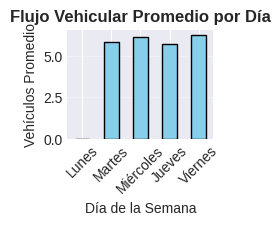

In [8]:
ax6 = plt.subplot(3, 3, 6)
flujo_dia = data.groupby('Dia_Nombre')['Total_Vehiculos'].mean().reindex(['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes'])
flujo_dia.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Flujo Vehicular Promedio por Día', fontsize=12, fontweight='bold')
plt.xlabel('Día de la Semana')
plt.ylabel('Vehículos Promedio')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

Text(0.5, 1.0, 'Matriz de Correlación')

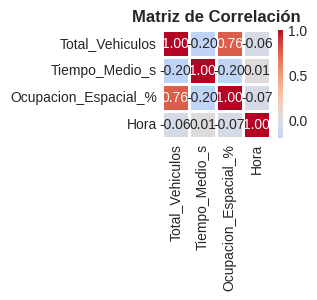

In [9]:
ax8 = plt.subplot(3, 3, 8)
correlacion = data[['Total_Vehiculos', 'Tiempo_Medio_s', 'Ocupacion_Espacial_%', 'Hora']].corr()
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Matriz de Correlación', fontsize=12, fontweight='bold')

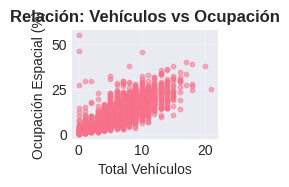

In [10]:
ax9 = plt.subplot(3, 3, 9)
plt.scatter(data['Total_Vehiculos'], data['Ocupacion_Espacial_%'], alpha=0.5, s=10)
plt.title('Relación: Vehículos vs Ocupación', fontsize=12, fontweight='bold')
plt.xlabel('Total Vehículos')
plt.ylabel('Ocupación Espacial (%)')
plt.grid(True, alpha=0.3)

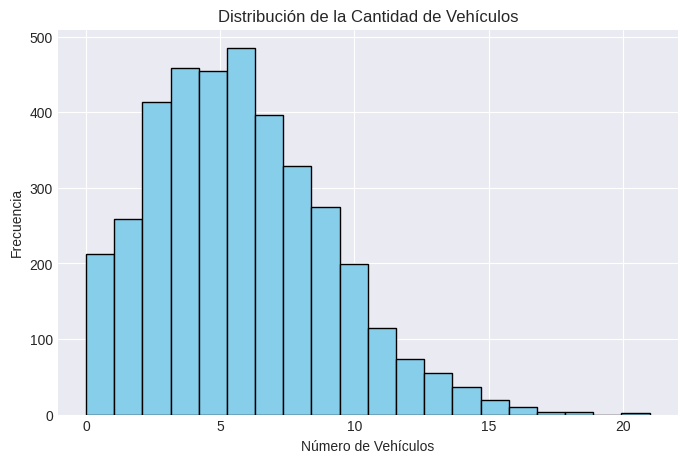

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(data['Total_Vehiculos'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de la Cantidad de Vehículos')
plt.xlabel('Número de Vehículos')
plt.ylabel('Frecuencia')
plt.show()